In [17]:
#installing packages
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

In [2]:
# reading data
raw_data = pd.read_csv("C:/Users/Niko/Downloads/YYZ_data.csv")

In [3]:
print(raw_data.head())
print(raw_data.columns)
print(raw_data.info())
print(raw_data.isna().sum())
print(raw_data.duplicated().sum())

  Op. Al. Name (Dominant) Arr Airport Code Arr City Name Arr Country Name  \
0              Air Canada              YVR     Vancouver           Canada   
1              Air Canada              YUL      Montreal           Canada   
2              Air Canada              YYC       Calgary           Canada   
3                 Westjet              YYC       Calgary           Canada   
4                 Westjet              YVR     Vancouver           Canada   

   Gateway1 Airport Code  Total Est. Pax  Time Series  
0                    NaN          919149         2022  
1                    NaN          572855         2022  
2                    NaN          532999         2022  
3                    NaN          532684         2022  
4                    NaN          398695         2022  
Index(['Op. Al. Name (Dominant)', 'Arr Airport Code', 'Arr City Name',
       'Arr Country Name', 'Gateway1 Airport Code', 'Total Est. Pax',
       'Time Series'],
      dtype='object')
<class 'pandas.

In [4]:
df = raw_data.copy()

df.columns = df.columns.str.strip()

#Renaming columns if needed
df = df.rename(columns={
    "Time Series": "year",
    "Op. Al. Name (Dominant)": "airline",
    "Arr Airport Code": "dest_airport",
    "Arr City Name": "dest_city",
    "Arr Country Name": "dest_country",
    "Gateway1 Airport Code": "gateway1",
    "Total Est. Pax": "passengers"
})

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["passengers"] = pd.to_numeric(df["passengers"], errors="coerce")

df = df.dropna(subset=["year", "passengers"])
df["year"] = df["year"].astype(int)

In [5]:
# Check for duplicates
df = df.drop_duplicates()

In [6]:
# Create market categories

# Forecast is about transborder = US
# non US international = all non Canada and non US markets

def classify_market(country):
    if country == "USA":
        return "Transborder_US"
    elif country == "Canada":
        return "Domestic"
    else:
        return "NonUS_International"

df["market"] = df["dest_country"].apply(classify_market)

In [7]:
# Keeping two markets I am interested in
yyz_markets = df[df["market"].isin(["Transborder_US", "NonUS_International", "Domestic"])].copy()

In [8]:
# Aggregate annual passenger demand
annual_market = (
    yyz_markets.groupby(["year", "market"], as_index=False)["passengers"].sum()
)

In [9]:
# Creating a pivot table for plotting and forecasting:
annual_pivot = annual_market.pivot(index="year", columns="market", values="passengers")
print(annual_pivot)

market  Domestic  NonUS_International  Transborder_US
year                                                 
2012     7438502              5156438         5524243
2013     6922704              5078647         5387683
2014     7044714              5671256         5146372
2015     7397158              6448609         5397041
2016     7937595              7150701         5918956
2017     8214750              8084839         6523626
2018     8569453              8562626         7032187
2019     8429354              8430935         6813681
2020     2993083              2131894         1851372
2021     4040549              1542234         1193612
2022     8012604              5792286         5374512
2023    10038465              8032233         6552496
2024     9390152              8569746         7052088
2025     9750656              8774069         6781144


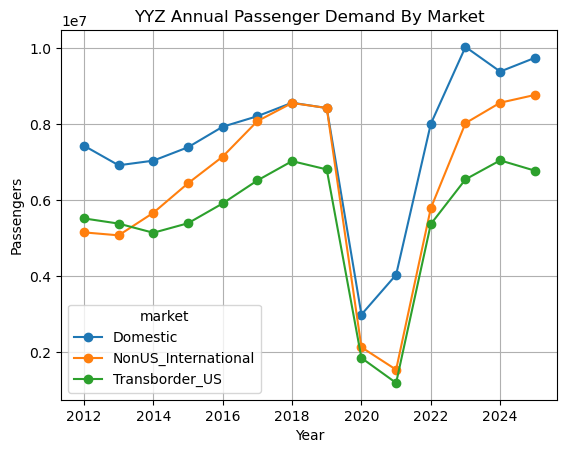

In [10]:
#Trend by market
annual_pivot.plot(marker="o")

plt.title("YYZ Annual Passenger Demand By Market")
plt.ylabel("Passengers")
plt.xlabel("Year")
plt.grid(True)
plt.show()

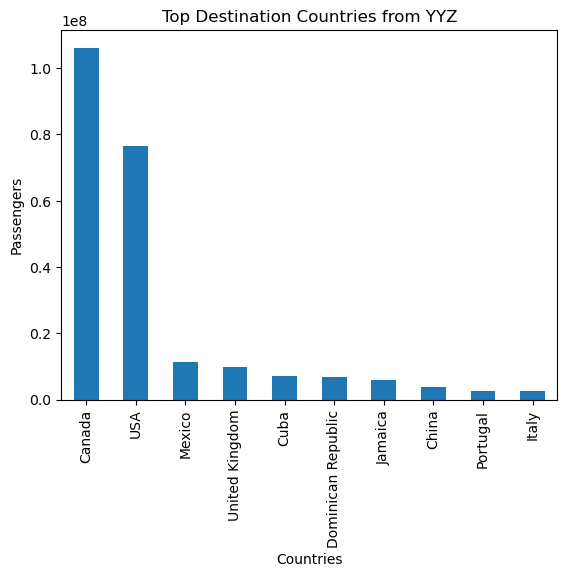

In [11]:
#Top destination countries
top_countries = (
    yyz_markets.groupby("dest_country")["passengers"].sum().sort_values(ascending=False).head(10)
)

top_countries.plot(kind="bar")
plt.title("Top Destination Countries from YYZ")
plt.ylabel("Passengers")
plt.xlabel("Countries")
plt.show()

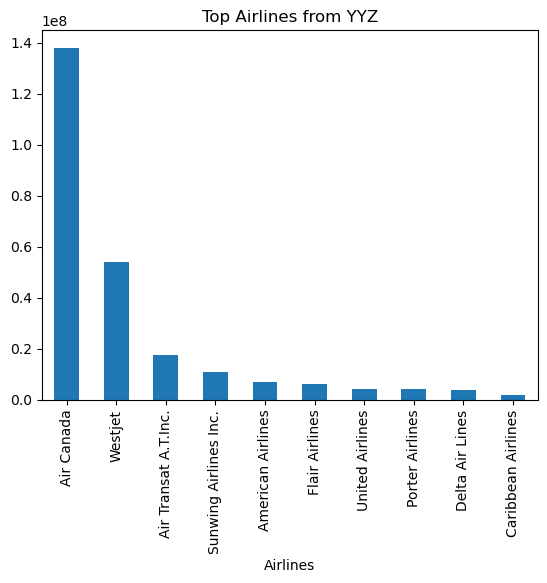

In [12]:
# Airlines by market
top_airlines = (
    yyz_markets.groupby("airline")["passengers"].sum().sort_values(ascending=False).head(10)
)
top_airlines.plot(kind="bar")
plt.title("Top Airlines from YYZ")
plt.xlabel("Passengers")
plt.xlabel("Airlines")
plt.show()

In [13]:
#Debugging/fixing code

#print(df["market"].value_counts())
#print(df["dest_country"].unique())

In [14]:
# Sticking with aggregating the annual market total

# Creating two forecast series relevant to airport capacity 
annual_pivot["International_total"] = (
    annual_pivot.get("Transborder_US", 0) + annual_pivot.get("NonUs_International", 0)
)

capacity_df = annual_pivot[["Domestic", "International_total"]].copy()

print(capacity_df)

market  Domestic  International_total
year                                 
2012     7438502              5524243
2013     6922704              5387683
2014     7044714              5146372
2015     7397158              5397041
2016     7937595              5918956
2017     8214750              6523626
2018     8569453              7032187
2019     8429354              6813681
2020     2993083              1851372
2021     4040549              1193612
2022     8012604              5374512
2023    10038465              6552496
2024     9390152              7052088
2025     9750656              6781144


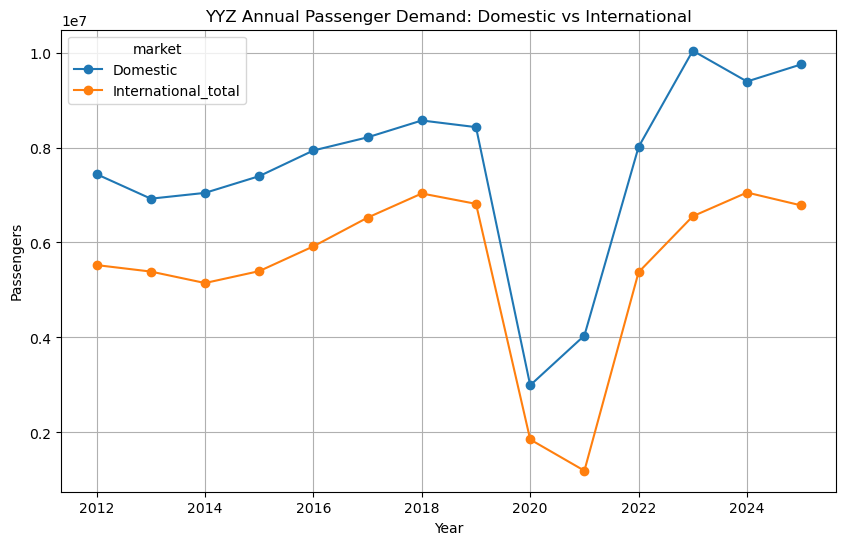

In [15]:
capacity_df.plot(marker="o", figsize=(10, 6))
plt.title("YYZ Annual Passenger Demand: Domestic vs International")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

In [16]:
# Hold out test - Train: up to 2022 & Test: 2023 - 2025

train = capacity_df[capacity_df.index <= 2022]
test = capacity_df[capacity_df.index > 2022]

print("Train years:", train.index.tolist())
print("Test years:", test.index.tolist())

Train years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Test years: [2023, 2024, 2025]


In [22]:
# ARIMA order search 

def find_best_arima(series, p_values=[0, 1, 2], d_values=[0, 1, 2], q_values=[0, 1, 2]):
    best_aic = np.inf
    best_order = None
    best_model = None

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    model = ARIMA(series, order=(p, d, q))
                    fitted = model.fit()
                    if fitted.aic < best_aic:
                        best_aic = fitted.aic
                        best_order = (p, d, q)
                        best_model = fitted
                except:
                    continue
    return best_order, best_model, best_aic

In [ ]:
# Fit ARIMA on training data

domestic_order, domestic_model_train, domestic_aic = find_best_arima(train["Domestic"])
intl_order, intl_model_train, intl_aic = find_best_arima(train["International_total"])

print("Best ARIMA for Domestic:", domestic_order, "AIC", domestic_aic)
print("Best ARIMA for International:", intl_order, "AIC", intl_aic)

Best ARIMA for Domestic: (0, 2, 0) AIC 296.0159593246234
Best ARIMA for International: (0, 2, 0) AIC 294.2522618040913


In [28]:
# Test set forecast accuracy
domestic_test_forecast = domestic_model_train.forecast(steps=len(test))
intl_test_forecast = intl_model_train.forecast(steps=len(test))

def forecast_metircs(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return pd.DataFrame({
        "Series": [label],
        "MAE":[mae],
        "RMSE": [rmse],
        "MAPE": [mape]         
    })

results = pd.concat([
    forecast_metircs(test["Domestic"], domestic_test_forecast, "Domestic"),
    forecast_metircs(test["International_total"], intl_test_forecast, "International")
], ignore_index=True)

print(results)

          Series           MAE          RMSE  MAPE
0       Domestic  6.230290e+06  7.082876e+06   NaN
1  International  6.941069e+06  7.696501e+06   NaN


In [29]:
# Refit ARIMA on full data
domestic_order_full, domestic_model_full, _ = find_best_arima(capacity_df["Domestic"])
intl_order_full, intl_model_full, _ = find_best_arima(capacity_df["International_total"])

print("Final Domestic ARIMA:", domestic_model_full)
print("Final International ARIMA:", intl_model_full)

Final Domestic ARIMA: <statsmodels.tsa.arima.model.ARIMAResultsWrapper object at 0x000002135A4D3550>
Final International ARIMA: <statsmodels.tsa.arima.model.ARIMAResultsWrapper object at 0x000002135A526340>


In [31]:
# Forecast 10 years ahead
forecast_horizon = 10
future_years = list(range(capacity_df.index.max() + 1, capacity_df.index.max() + 1 + forecast_horizon))

domestic_forecast = domestic_model_full.forecast(steps=forecast_horizon)
intl_forecast = intl_model_full.forecast(steps=forecast_horizon)

forecast_df = pd.DataFrame({
    "Year": future_years,
    "Domestic_Forecast": domestic_forecast.values,
    "International_Forecast": intl_forecast.values
}).set_index("Year")

print(forecast_df)

      Domestic_Forecast  International_Forecast
Year                                           
2026       1.043907e+07               6510200.0
2027       1.101908e+07               6239256.0
2028       1.159909e+07               5968312.0
2029       1.217910e+07               5697368.0
2030       1.275911e+07               5426424.0
2031       1.333912e+07               5155480.0
2032       1.391912e+07               4884536.0
2033       1.449913e+07               4613592.0
2034       1.507914e+07               4342648.0
2035       1.565915e+07               4071704.0


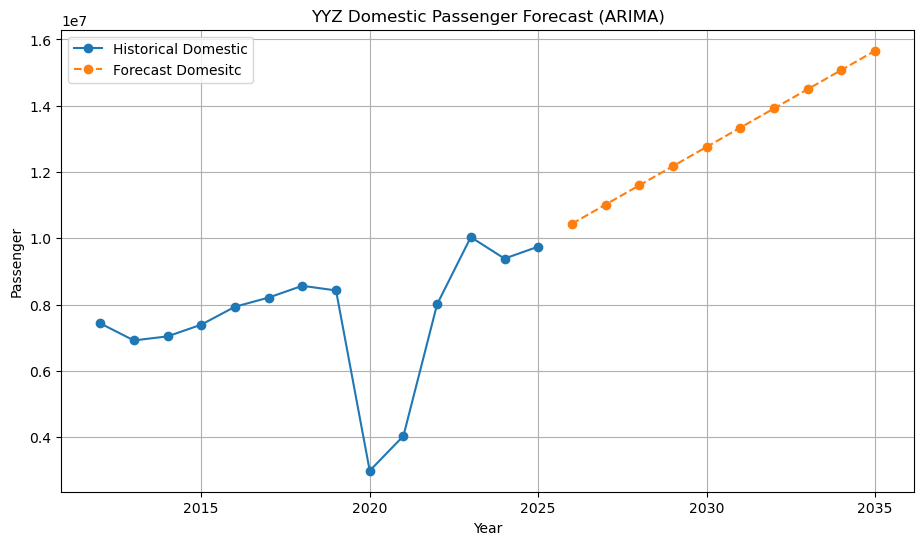

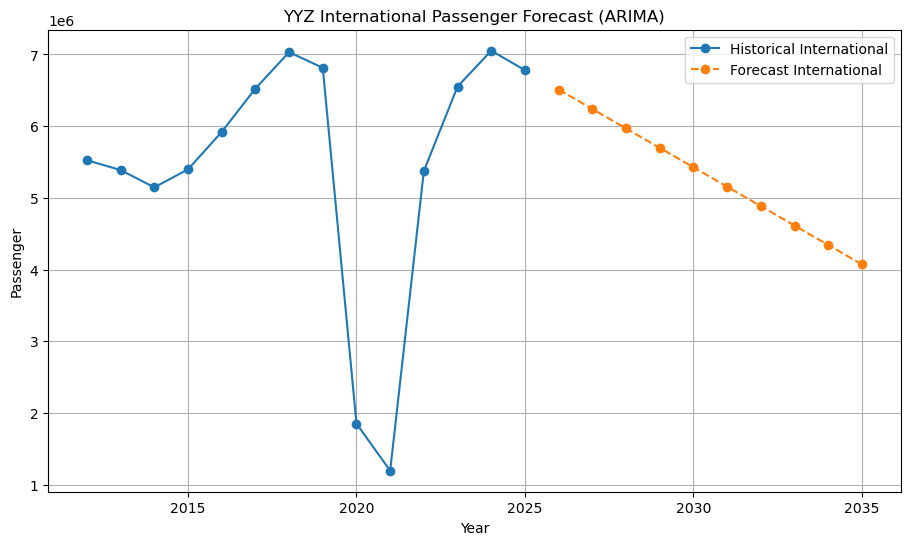

In [35]:
# Plot final forecasts


#Domestic
plt.figure(figsize=(11, 6))
plt.plot(capacity_df.index, capacity_df["Domestic"], marker="o", label="Historical Domestic")
plt.plot(forecast_df.index, forecast_df["Domestic_Forecast"], marker="o", linestyle="--", label="Forecast Domesitc")
plt.title("YYZ Domestic Passenger Forecast (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Passenger")
plt.grid(True)
plt.legend()
plt.show()

#International
plt.figure(figsize=(11, 6))
plt.plot(capacity_df.index, capacity_df["International_total"], marker="o", label="Historical International")
plt.plot(forecast_df.index, forecast_df["International_Forecast"], marker="o", linestyle="--", label="Forecast International")
plt.title("YYZ International Passenger Forecast (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Passenger")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
# Compare pressure on capacity 
forecast_df["Int_minus_domestic"] = (
    forecast_df["International_Forecast"] - forecast_df["Domestic_Forecast"]
)

forecast_df["Priority"] = np.where(
    forecast_df["International_Forecast"] > forecast_df["Domestic_Forecast"],
    "International infrastructure priority",
    "Domestic infrastucture priority"
)

print(forecast_df)

      Domestic_Forecast  International_Forecast  Int_minus_domestic  \
Year                                                                  
2026       1.043907e+07               6510200.0       -3.928873e+06   
2027       1.101908e+07               6239256.0       -4.779825e+06   
2028       1.159909e+07               5968312.0       -5.630778e+06   
2029       1.217910e+07               5697368.0       -6.481730e+06   
2030       1.275911e+07               5426424.0       -7.332683e+06   
2031       1.333912e+07               5155480.0       -8.183635e+06   
2032       1.391912e+07               4884536.0       -9.034588e+06   
2033       1.449913e+07               4613592.0       -9.885540e+06   
2034       1.507914e+07               4342648.0       -1.073649e+07   
2035       1.565915e+07               4071704.0       -1.158745e+07   

                             Priority  
Year                                   
2026  Domestic infrastucture priority  
2027  Domestic infrastuctur